<a href="https://colab.research.google.com/github/kiplimoowen-cmyk/ML-Group-Summ-/blob/k-NN-Classification/summative_steps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Summative Lab

## Overview

This lab applies machine learning techniques to three different business problems: wine classification feed recommendation and regional crime pattern analysis.

The analysis follows the machine learning workflow of data preparation, exploratory analysis, preprocessing, model development, evaluation and interpretation.

### Projects

1. **Wine Classification** - Using PCA and k-Nearest Neighbors (k-NN) to classify wine varieties.
2. **Agricultural Feed Recommendation** - Using PCA and similarity measures to identify similar feed types.
3. **Regional Crime Pattern Analysis** - Using K-Means and Gaussian Mixture Models to identify patterns in crime data.


 five main sections:

**1** - Data Preparation: Load, inspect, clean, summarize and standardize the three datasets.

**2** - k-NN Classification: Prepare the Wine target, apply PCA, tune k-NN and evaluate the final classification model.

**3** - Recommendation System: Standardize the Chickwts data, apply PCA, calculate cosine similarity and generate feed recommendations.

**4** - Clustering: Prepare the USArrests data, apply PCA, determine suitable cluster numbers and perform K-Means and GMM clustering.

**5** - Evaluation, Visualization & Integration: Present the results from all three tasks using appropriate visualizations and combine the findings into the final notebook-


## **Business Understanding**

This project applies machine learning to three different business problems: wine classification, agricultural feed recommendation, and regional crime pattern analysis. Each problem uses a different machine learning approach to extract useful information from the data.

### 1 Wine Classification System

#### Business Problem

A premium wine distributor wants to automatically classify wines based on their chemical properties. PCA and a k-Nearest Neighbors (k-NN) model will be used to reduce the dimensionality of the data and classify the different wine varieties.

### 2 Agricultural Feed Recommendation System

#### Business Problem

A poultry business wants to identify feed types that have similar characteristics based on the weight of chickens associated with each feed type. PCA and cosine similarity will be used to compare the feed types and generate recommendations for similar feeds.

### 3 Regional Crime Pattern Analysis

#### Business Problem

A public safety organization wants to identify groups of states with similar crime patterns. PCA will be used to reduce the data for visualization, while K-Means and Gaussian Mixture Models (GMM) will be used to identify and compare different crime clusters.


# **1 - Data Preparation**

In [2]:
#Required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
# Load the Wine dataset
wine = pd.read_csv("wine.csv")

wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [5]:
#missing values
wine.isnull().sum()

,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


In [6]:
#duplicates
wine.duplicated().sum()

np.int64(0)

In [7]:
#wine summary
wine.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


The dataset contains 178 observations and 14 variables, while the target variable contains three wine classes: 0, 1 and 2. There are no missing values or duplicate records. The features have different ranges, so the numerical features will be standardized using StandardScaler before the dataset is passed on for further analysis.


In [8]:
#standardization of numerical features
wine_features = wine.drop('target', axis=1)

wine_scaler = StandardScaler()

wine_scaled = wine_scaler.fit_transform(wine_features)

wine_scaled = pd.DataFrame(
    wine_scaled,
    columns=wine_features.columns
)

wine_scaled.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


## 2. Chickwts Dataset

The Chickwts dataset contains information about chicken weights under different feed types. The dataset will be inspected for missing values, duplicate records, data types and summary statistics before the numerical features are standardized.


In [9]:
#Chickwts dataset
chickwts = pd.read_csv("chickwts.csv")

chickwts.head()

,weight,feed
0,179,horsebean
1,160,horsebean
2,136,horsebean
3,227,horsebean
4,217,horsebean


In [10]:
chickwts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   weight  71 non-null     int64 
 1   feed    71 non-null     object
dtypes: int64(1), object(1)
memory usage: 1.2+ KB


In [11]:
# missing values
chickwts.isnull().sum()

,0
weight,0
feed,0


In [12]:
#duplicates
chickwts.duplicated().sum()

np.int64(1)

In [13]:
# Summary
chickwts.describe()

,weight
count,71.000000
mean,261.309859
std,78.073700
min,108.000000
25%,204.500000
50%,258.000000
75%,323.500000
max,423.000000


In [14]:
# Standardization of numerical feature
chickwts_scaler = StandardScaler()

chickwts_scaled = chickwts_scaler.fit_transform(
    chickwts[['weight']]
)

chickwts_scaled = pd.DataFrame(
    chickwts_scaled,
    columns=['weight']
)

chickwts_scaled.head()

,weight
0,-1.061762
1,-1.306854
2,-1.616444
3,-0.442583
4,-0.571578


## 3. USArrests Dataset

The USArrests dataset contains crime statistics for different states which will be inspected for missing values, duplicate records, data types and summary statistics before the numerical features are standardized.


In [15]:
#USArrests dataset
usarrests = pd.read_csv("USArrests.csv")

usarrests.head()

,rownames,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


In [16]:
usarrests.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rownames  50 non-null     object 
 1   Murder    50 non-null     float64
 2   Assault   50 non-null     int64  
 3   UrbanPop  50 non-null     int64  
 4   Rape      50 non-null     float64
dtypes: float64(2), int64(2), object(1)
memory usage: 2.1+ KB


In [17]:
#missing values
usarrests.isnull().sum()#

,0
rownames,0
Murder,0
Assault,0
UrbanPop,0
Rape,0


In [18]:
#duplicate rows
usarrests.duplicated().sum()

np.int64(0)

In [19]:
#summary
usarrests.describe()

,Murder,Assault,UrbanPop,Rape
count,50.00000,50.000000,50.000000,50.000000
mean,7.78800,170.760000,65.540000,21.232000
std,4.35551,83.337661,14.474763,9.366385
min,0.80000,45.000000,32.000000,7.300000
25%,4.07500,109.000000,54.500000,15.075000
50%,7.25000,159.000000,66.000000,20.100000
75%,11.25000,249.000000,77.750000,26.175000
max,17.40000,337.000000,91.000000,46.000000


In [20]:
# Standardization of numerical features
usarrests_features = usarrests[['Murder', 'Assault', 'UrbanPop', 'Rape']]

usarrests_scaler = StandardScaler()

usarrests_scaled = usarrests_scaler.fit_transform(usarrests_features)

usarrests_scaled = pd.DataFrame(
    usarrests_scaled,
    columns=usarrests_features.columns
)

usarrests_scaled.head()

,Murder,Assault,UrbanPop,Rape
0,1.255179,0.790787,-0.526195,-0.003451
1,0.513019,1.118060,-1.224067,2.509424
2,0.072361,1.493817,1.009122,1.053466
3,0.234708,0.233212,-1.084492,-0.186794
4,0.281093,1.275635,1.776781,2.088814


The numerical crime variables were standardized using StandardScaler with the state names being kept unchanged because they are identifiers rather than numerical features.


## Dataset Preparation Summary

The Wine, Chickwts, and USArrests datasets were loaded and checked for missing values, duplicate records, data types and summary statistics. The relevant numerical features were standardized using StandardScaler.


# **2 - k-NN Classification**

In [22]:
## Step 1: Confirm the Target Variable

# Confirm the target labels
wine['target'].unique()
wine['target'].value_counts()


,count
target,
1,71
0,59
2,48


The `target` column already contains numeric class labels (0, 1, 2) corresponding to the three wine cultivars, so no additional label encoding is required. This is confirmed by inspecting the unique values and class counts above

In [23]:
## Step 2: Train-Test Split

X = wine_scaled
y = wine['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((142, 13), (36, 13))

The data is split into training (80%) and test (20%) sets, using stratification on the target to preserve the class proportions in both sets. The split is done **before** PCA so that the transformation is learned only from the training data, avoiding information leakage from the test set.

In [24]:
## Step 3: Apply PCA (Retain 95% Variance)

pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Number of components retained: {pca.n_components_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.4f}")

Number of components retained: 10
Total variance explained: 0.9629


In [ ]:
# Visualize cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Explained Variance (Wine Dataset)')
plt.legend()
plt.show()

PCA reduces the original 13 chemical feature dimensions down to the smallest number of principal components needed to retain at least 95% of the variance in the training data. This improves model efficiency and reduces the risk of overfitting from correlated features (e.g. phenols and flavanoids).

In [25]:
## Step 4: Hyperparameter Tuning with GridSearchCV
param_grid = {
    'n_neighbors': list(range(1, 21)),
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

knn = KNeighborsClassifier()

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_pca, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

Best parameters: {'metric': 'euclidean', 'n_neighbors': 18}
Best cross-validation accuracy: 0.9791


`GridSearchCV` performs 5-fold cross-validation across a range of `k` values (1–20) and three distance metrics (Euclidean, Manhattan, Minkowski) to identify the combination that maximizes classification accuracy on the training data.

In [27]:
## Step 5: Train Final Model with Best Parameters
best_knn = grid_search.best_estimator_

best_knn.fit(X_train_pca, y_train)

y_pred = best_knn.predict(X_test_pca)


The final k-NN classifier is trained on the PCA-transformed training data using the optimal `n_neighbors` and `metric` identified by the grid search, then used to predict wine classes on the held-out test set.

In [28]:

## Step 6: Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))


Test Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



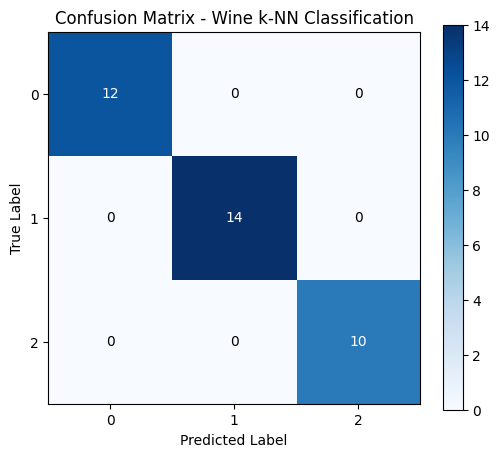

In [29]:
# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix - Wine k-NN Classification')
plt.colorbar()
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center',
                 color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.xticks([0, 1, 2])
plt.yticks([0, 1, 2])
plt.show()

## k-NN Classification Summary

Using PCA to retain 95% of the variance in the standardized chemical features, combined with a grid search over neighborhood size and distance metric, the tuned k-NN classifier achieves strong test-set accuracy in distinguishing the three wine cultivars. The confusion matrix and classification report (precision, recall, F1-score per class) confirm the model's reliability, and results are ready to be handed off to Person 5 for cross-project visualization and final write-up.

# **3 - Feed Recommendation System**

# **4 - Crime Pattern Clustering**

# **5 - Evaluation, Visualization & Integration**